In [31]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor

In [7]:
# df = pd.read_csv("/Users/apple/Documents Local/Mubashir Code/ML/Machine Learning with Tree-Based Models in Python/Practice/Air Quality/AirQualityUCI.csv",sep=';')
df = pd.read_csv(r"AirQualityUCI.csv",sep=';')
df = df.drop(['Unnamed: 15','Unnamed: 16','Date','Time'],axis=1)

df = df.dropna()

df.isna().sum()

CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

In [8]:
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         9357 non-null   str    
 1   PT08.S1(CO)    9357 non-null   float64
 2   NMHC(GT)       9357 non-null   float64
 3   C6H6(GT)       9357 non-null   str    
 4   PT08.S2(NMHC)  9357 non-null   float64
 5   NOx(GT)        9357 non-null   float64
 6   PT08.S3(NOx)   9357 non-null   float64
 7   NO2(GT)        9357 non-null   float64
 8   PT08.S4(NO2)   9357 non-null   float64
 9   PT08.S5(O3)    9357 non-null   float64
 10  T              9357 non-null   str    
 11  RH             9357 non-null   str    
 12  AH             9357 non-null   str    
dtypes: float64(8), str(5)
memory usage: 1.1 MB


In [10]:
for col in df.columns:
    if df[col].dtype == 'str':
        df[col] = df[col].str.replace(',', '.').astype(float)


In [11]:
df.info()
df.head()
df = df[df['T'] >= -20]

<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         9357 non-null   float64
 1   PT08.S1(CO)    9357 non-null   float64
 2   NMHC(GT)       9357 non-null   float64
 3   C6H6(GT)       9357 non-null   float64
 4   PT08.S2(NMHC)  9357 non-null   float64
 5   NOx(GT)        9357 non-null   float64
 6   PT08.S3(NOx)   9357 non-null   float64
 7   NO2(GT)        9357 non-null   float64
 8   PT08.S4(NO2)   9357 non-null   float64
 9   PT08.S5(O3)    9357 non-null   float64
 10  T              9357 non-null   float64
 11  RH             9357 non-null   float64
 12  AH             9357 non-null   float64
dtypes: float64(13)
memory usage: 950.4 KB


In [12]:
df.corr()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
CO(GT),1.000000,0.117828,0.130118,0.068549,0.077325,0.532309,-0.081036,0.670099,-0.060633,0.122234,-0.130533,-0.020492,-0.187919
PT08.S1(CO),0.117828,1.000000,0.250628,0.883795,0.892964,0.564630,-0.771938,0.313563,0.682881,0.899324,0.048627,0.114606,0.135324
NMHC(GT),0.130118,0.250628,1.000000,0.136698,0.134317,0.000738,0.052192,0.106870,0.213850,0.111533,-0.068140,-0.014311,-0.123688
C6H6(GT),0.068549,0.883795,0.136698,1.000000,0.981950,0.538118,-0.735744,0.265851,0.765731,0.865689,0.198956,-0.061681,0.167972
PT08.S2(NMHC),0.077325,0.892964,0.134317,0.981950,1.000000,0.534201,-0.796703,0.285569,0.777254,0.880578,0.241373,-0.090380,0.186933
NOx(GT),0.532309,0.564630,0.000738,0.538118,0.534201,1.000000,-0.503144,0.821199,0.143447,0.622205,-0.242007,0.111562,-0.210105
PT08.S3(NOx),-0.081036,-0.771938,0.052192,-0.735744,-0.796703,-0.503144,1.000000,-0.287317,-0.538468,-0.796569,-0.145112,-0.056740,-0.232017
NO2(GT),0.670099,0.313563,0.106870,0.265851,0.285569,0.821199,-0.287317,1.000000,0.024735,0.338367,-0.139509,-0.082190,-0.257482
PT08.S4(NO2),-0.060633,0.682881,0.213850,0.765731,0.777254,0.143447,-0.538468,0.024735,1.000000,0.591144,0.561270,-0.032188,0.629641
PT08.S5(O3),0.122234,0.899324,0.111533,0.865689,0.880578,0.622205,-0.796569,0.338367,0.591144,1.000000,-0.027172,0.124956,0.070751


<Axes: >

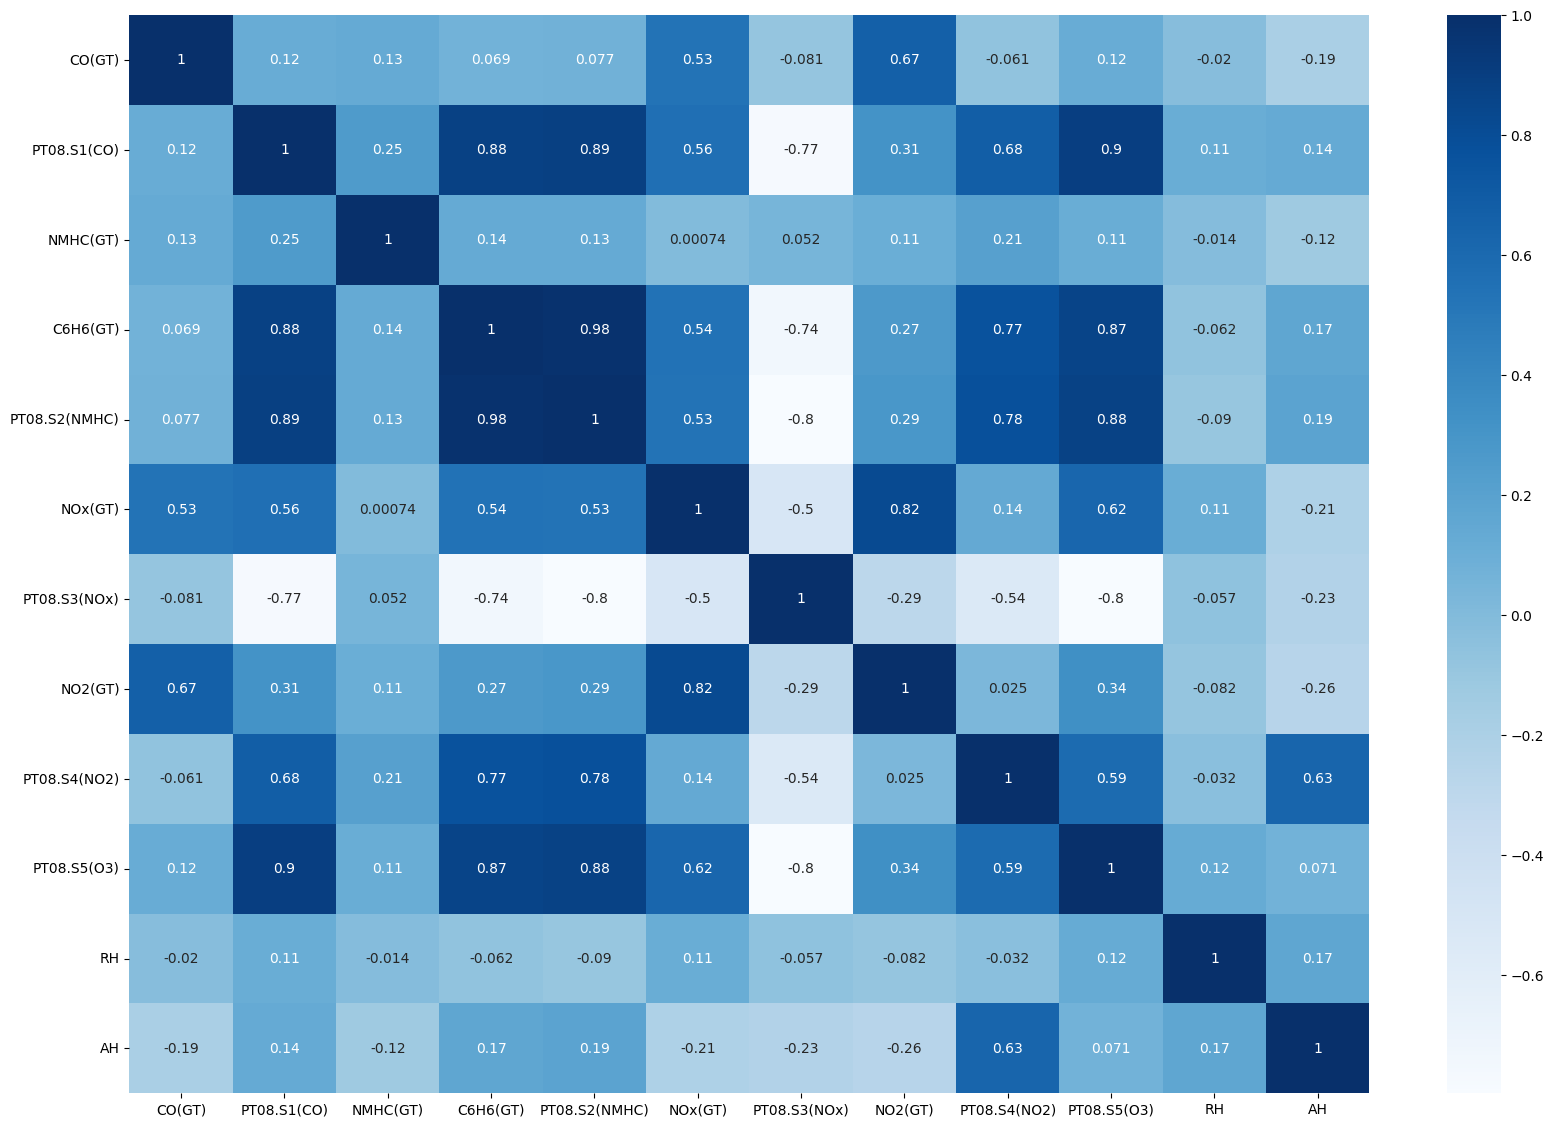

In [13]:
target = df['T'].values
feature = df.drop("T",axis=1)
plt.figure(figsize=(20,14))
sns.heatmap(feature.corr(),annot=True,cmap='Blues')

In [14]:
corr = df.corr(numeric_only=True)
corr['T'].sort_values(ascending=False)

T                1.000000
AH               0.656397
PT08.S4(NO2)     0.561270
PT08.S2(NMHC)    0.241373
C6H6(GT)         0.198956
PT08.S1(CO)      0.048627
PT08.S5(O3)     -0.027172
NMHC(GT)        -0.068140
CO(GT)          -0.130533
NO2(GT)         -0.139509
PT08.S3(NOx)    -0.145112
NOx(GT)         -0.242007
RH              -0.578621
Name: T, dtype: float64

In [15]:
df['T'].describe()



count    8991.000000
mean       18.317829
std         8.832116
min        -1.900000
25%        11.800000
50%        17.800000
75%        24.400000
max        44.600000
Name: T, dtype: float64

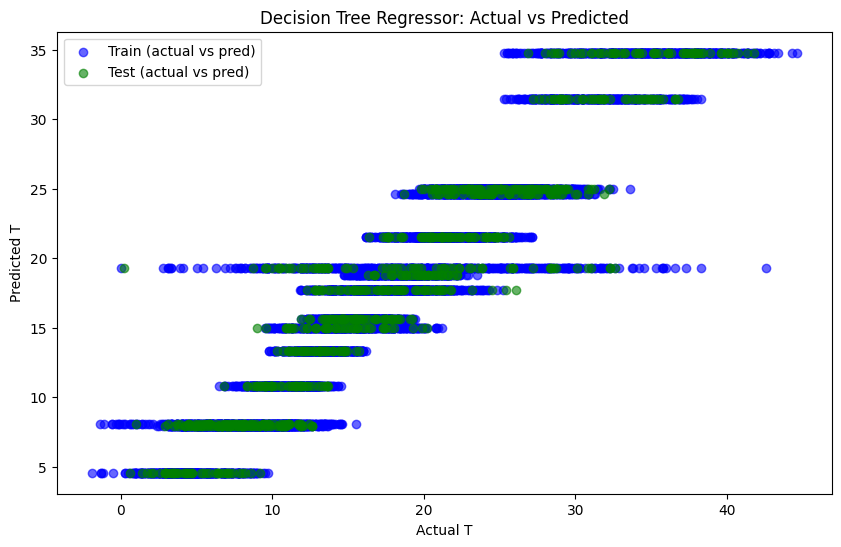

Train R²: 0.8786881343852431
Test R²: 0.8759461439597602
Train MSE: 9.430126529542639
Test MSE: 9.961181583641903


In [16]:
target = df['T'].values
feature = df.drop("T",axis=1).values

X_train, X_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.1, random_state=42
)

dt = DecisionTreeRegressor(max_depth=5, min_samples_leaf=0.05 , random_state=1)
dt.fit(X_train, y_train)

# Predict on train and test so x and y have the same length for scatter
y_pred_train = dt.predict(X_train)
y_pred_test = dt.predict(X_test)

plt.figure(figsize=(10, 6))

plt.scatter(y_train, y_pred_train, color='blue', alpha=0.6, label='Train (actual vs pred)')
plt.scatter(y_test, y_pred_test, color='green', alpha=0.6, label='Test (actual vs pred)')

# plot perfect-prediction line
# min_val = min(y_train.min(), y_test.min(), y_pred_train.min(), y_pred_test.min())
# max_val = max(y_train.max(), y_test.max(), y_pred_train.max(), y_pred_test.max())
# plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Perfect prediction')

plt.xlabel('Actual T')
plt.ylabel('Predicted T')
plt.legend()
plt.title('Decision Tree Regressor: Actual vs Predicted')
plt.show()



print("Train R²:", r2_score(y_train, y_pred_train))
print("Test R²:", r2_score(y_test, y_pred_test))

print("Train MSE:", MSE(y_train, y_pred_train))
print("Test MSE:", MSE(y_test, y_pred_test))




# Cross Validation

In [17]:
# Set seed for reproducibly 
SEED = 123

# Split the 70% training and 30% test set 
X_train, X_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.3, random_state=SEED
)


# Instantiate a decision tree regressor 
dt = DecisionTreeRegressor(
    max_depth=6,
    min_samples_leaf=1,
    random_state=SEED
)


# Evaluate the list of MSE obtained by 10 Fold CV
# Set n jobs to -1 in order to exploit all CPU cores in computation
MSE_CV = - cross_val_score(dt,X_train,y_train,cv=10,scoring='neg_mean_squared_error',n_jobs=-1)

# Fit the dt to training set 
dt.fit(X_train,y_train)

# Predict the labels of training set 
y_predict_train = dt.predict(X_train)

# Predcit the labels of test set 
y_predict_test = dt.predict(X_test)

# CV MSE
print('CV MSE: {:.2f}'.format(MSE_CV.mean()))

# Training set MSE
print('Train MSE: {:.2f}'.format(MSE(y_train,y_predict_train)))

# Test Set 
print('Test MSE: {:.2f}'.format(MSE(y_test,y_predict_test)))


# Training set MSE
print('Train R^2: {:.2f}'.format(r2_score(y_train,y_predict_train)))

# Test Set 
print('Test R^2: {:.2f}'.format(r2_score(y_test,y_predict_test)))

CV MSE: 2.48
Train MSE: 2.16
Test MSE: 2.52
Train R^2: 0.97
Test R^2: 0.97


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_leaf': [1, 5, 10, 20]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5
)

grid.fit(X_train, y_train)
print(grid.best_params_)


{'max_depth': 6, 'min_samples_leaf': 1}


In [19]:
X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.3,random_state=SEED)

rf = RandomForestRegressor(n_estimators=400,min_samples_leaf=1,random_state=SEED)

# Fit 'rf' to training set
rf.fit(X_train,y_train)

# Predict the test set labels 'y_pred'
y_pred_test = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

# Evaluate the test set RMSE

rmse_test = MSE(y_test,y_pred_test) ** 0.5
rmse_train = MSE(y_train,y_pred_train) ** 0.5

print('Test set RMSE of rf : {:.2f}'.format(rmse_test))
print('Test set MSE of rf : {:.2f}'.format(MSE(y_test,y_pred_test)))

print('Train set RMSE of rf : {:.2f}'.format(rmse_train))
print('Train set MSE of rf : {:.2f}'.format(MSE(y_train,y_pred_train)))

train_r2 = r2_score(y_train,y_predict_train)
test_r2 = r2_score(y_test,y_predict_test)
print(train_r2)
print(test_r2)


Test set RMSE of rf : 0.23
Test set MSE of rf : 0.05
Train set RMSE of rf : 0.11
Train set MSE of rf : 0.01
0.9726247678286435
0.9667171042041091


| Model                             | Parameters                           | Train MSE | Test MSE | CV MSE | Train R² | Test R² | Test RMSE |
| --------------------------------- | ------------------------------------ | --------- | -------- | ------ | -------- | ------- | --------- |
| Decision Tree (original)          | max_depth=1                          | 9.43      | 9.96     | —      | 0.8795   | 0.8759  | 3.15      |
| Decision Tree (after Grid Search) | max_depth=6, min_samples_leaf=1      | 2.16      | 2.52     | 2.48   | 0.97     | 0.97    | 1.59      |
| Random Forest                     | n_estimators=400, min_samples_leaf=1 | 0.01      | 0.05     | —      | 0.97       | 0.96    | 0.23      |


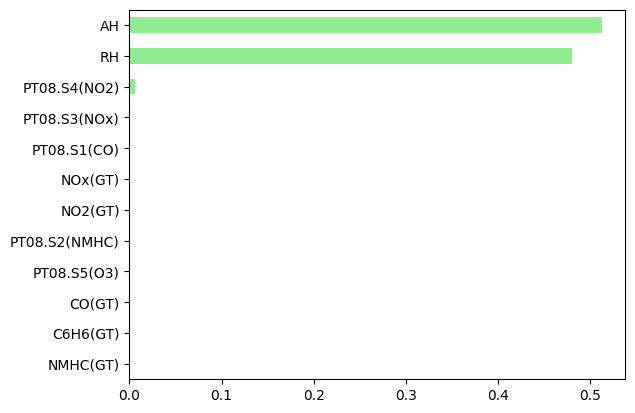

In [20]:
# Create a pd.Series of features importances 
importances_rf = pd.Series(rf.feature_importances_,index=df.drop("T",axis=1).columns)

# Sort importances_rf 
sorted_importances_rf = importances_rf.sort_values()

# Make a horizontal bar plot
sorted_importances_rf.plot(kind='barh',color='lightgreen')

plt.show()



In [21]:
from sklearn.ensemble import AdaBoostRegressor

# Adaboosting on Data

In [ ]:
target = df['T'].values
feature = df.drop("T",axis=1).values

X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.3,random_state=SEED)

dt = DecisionTreeRegressor(
    max_depth=5,
    random_state=SEED
)

adb_reg = AdaBoostRegressor(estimator=dt,n_estimators=500,learning_rate=0.01)
adb_reg.fit(X_train,y_train)


# Predict the test set labels 'y_pred'
y_pred_test = adb_reg.predict(X_test)
y_pred_train = adb_reg.predict(X_train)

# Evaluate the test set RMSE

rmse_test = MSE(y_test,y_pred_test) ** 0.5
rmse_train = MSE(y_train,y_pred_train) ** 0.5

print('Test set RMSE of adb_reg : {:.2f}'.format(rmse_test))
print('Test set MSE of adb_reg : {:.2f}'.format(MSE(y_test,y_pred_test)))

print('Train set RMSE of adb_reg : {:.2f}'.format(rmse_train))
print('Train set MSE of adb_reg : {:.2f}'.format(MSE(y_train,y_pred_train)))


Test set RMSE of adb_reg : 1.12
Test set MSE of adb_reg : 1.25
Train set RMSE of adb_reg : 1.09
Train set MSE of adb_reg : 1.18


# Gradient Boosting

In [34]:
X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.3,random_state=1)

gbt = GradientBoostingRegressor(n_estimators=150,max_depth=4,random_state=1)
gbt.fit(X_train,y_train)

# Predict the test set labels 'y_pred'
y_pred_test = gbt.predict(X_test)
y_pred_train = gbt.predict(X_train)

# Evaluate the test set RMSE

rmse_test = MSE(y_test,y_pred_test) ** 0.5
rmse_train = MSE(y_train,y_pred_train) ** 0.5

print('Test set RMSE of gbt : {:.2f}'.format(rmse_test))
print('Test set MSE of gbt : {:.2f}'.format(MSE(y_test,y_pred_test)))

print('Train set RMSE of gbt : {:.2f}'.format(rmse_train))
print('Train set MSE of gbt : {:.2f}'.format(MSE(y_train,y_pred_train)))


Test set RMSE of gbt : 0.37
Test set MSE of gbt : 0.14
Train set RMSE of gbt : 0.28
Train set MSE of gbt : 0.08


In [36]:
sgbt = GradientBoostingRegressor(max_depth=1,subsample=0.8,max_features=0.2,n_estimators=300,random_state=1)

sgbt.fit(X_train,y_train)

# Predict the test set labels 'y_pred'
y_pred_test = sgbt.predict(X_test)
y_pred_train = sgbt.predict(X_train)

# Evaluate the test set RMSE

rmse_test = MSE(y_test,y_pred_test) ** 0.5
rmse_train = MSE(y_train,y_pred_train) ** 0.5

print('Test set RMSE of sgbt : {:.2f}'.format(rmse_test))
print('Test set MSE of sgbt : {:.2f}'.format(MSE(y_test,y_pred_test)))

print('Train set RMSE of sgbt : {:.2f}'.format(rmse_train))
print('Train set MSE of sgbt : {:.2f}'.format(MSE(y_train,y_pred_train)))

Test set RMSE of sgbt : 1.94
Test set MSE of sgbt : 3.76
Train set RMSE of sgbt : 1.83
Train set MSE of sgbt : 3.35
